In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

In [2]:
# open files
path = "/global/homes/n/nagarwal/graph-ufs/prototypes/ocn_only/bathymetry"

bathy=xr.open_dataset(os.path.join(path, "topog.nc")) # central topography file
edits=xr.open_dataset(os.path.join(path, "All_edits.nc")) # edits in the above

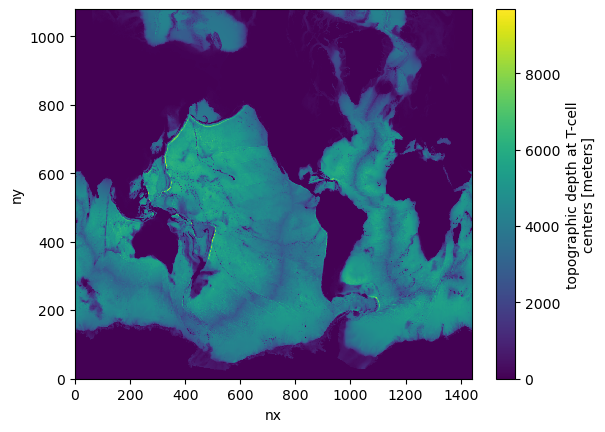

In [3]:
bathy.depth.plot()
plt.show()

In [4]:
# edit bathymetry
for i in edits.nEdits.values:
    bathy.depth[edits.jEdit[i].values, edits.iEdit[i].values]=abs(edits.zEdit[i].values)

In [5]:
# set max and min depths (as done in MOM6)
bathy.depth[:,:]=xr.where(bathy.depth < 9.5,9.5,bathy.depth)
bathy.depth[:,:]=xr.where(bathy.depth > 6500,6500,bathy.depth)

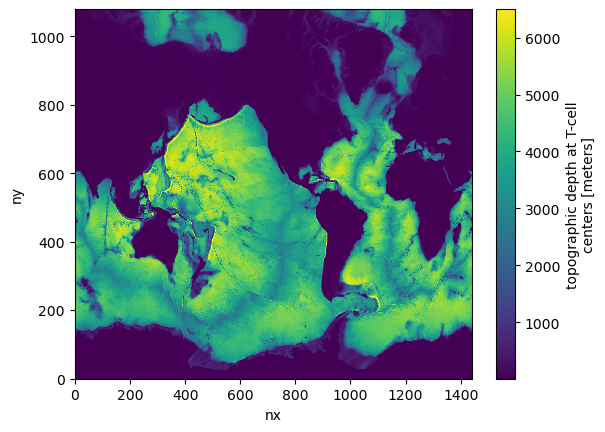

In [6]:
bathy.depth.plot()
plt.show()

In [7]:
bathy.to_netcdf(os.path.join(path, "topog_all_edited.nc"))

## Regridded Bathymetry

In [8]:
path = "/global/homes/n/nagarwal/graph-ufs/prototypes/ocn_only/bathymetry/regrid-bathymetry/"
bathy_regrid = xr.open_dataset(os.path.join(path, "bathymetry.gaussian.0.25-degree.nc")) # central topography file

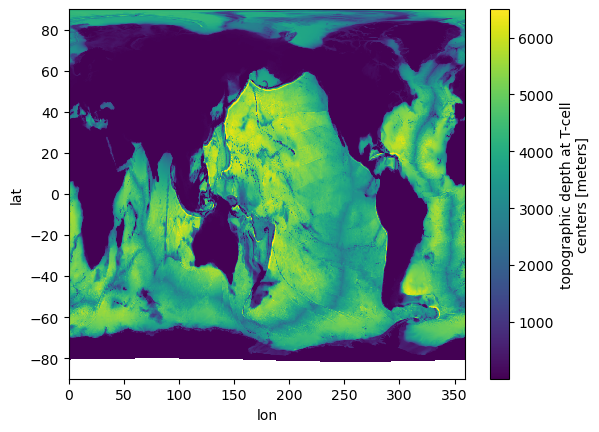

In [9]:
bathy_regrid.depth.plot()
plt.show()

In [10]:
bathy_regrid

<xarray.Dataset> Size: 5MB
Dimensions:  (lat: 768, lon: 1536)
Coordinates:
  * lon      (lon) float64 12kB 0.0 0.2344 0.4688 0.7031 ... 359.3 359.5 359.8
  * lat      (lat) float64 6kB 89.82 89.59 89.35 89.12 ... -89.35 -89.59 -89.82
Data variables:
    depth    (lat, lon) float32 5MB ...
Attributes:
    regrid_method:  conservative

In [11]:
# store as zarr
zarr_store = "bathymetry.gaussian.0.25-degree.zarr"
bathy_regrid.to_zarr(os.path.join(path, zarr_store))

In [12]:
# open and check the zarr store
bathy_zarr = xr.open_zarr(os.path.join(path, zarr_store))
bathy_zarr

<xarray.Dataset> Size: 5MB
Dimensions:  (lat: 768, lon: 1536)
Coordinates:
  * lat      (lat) float64 6kB 89.82 89.59 89.35 89.12 ... -89.35 -89.59 -89.82
  * lon      (lon) float64 12kB 0.0 0.2344 0.4688 0.7031 ... 359.3 359.5 359.8
Data variables:
    depth    (lat, lon) float32 5MB dask.array<chunksize=(192, 768), meta=np.ndarray>
Attributes:
    regrid_method:  conservative

In [13]:
ocn = xr.open_zarr(
    "gs://noaa-ufs-gefsv13replay/ufs-hr1/0.25-degree/06h-freq/zarr/mom6.zarr",
    storage_options={"token": "anon"},
)
ocn

<xarray.Dataset> Size: 80TB
Dimensions:    (time: 43826, lat: 768, lon: 1536, zl: 75, z_l: 75)
Coordinates:
    cftime     (time) object 351kB dask.array<chunksize=(21913,), meta=np.ndarray>
    ftime      (time) timedelta64[ns] 351kB dask.array<chunksize=(21913,), meta=np.ndarray>
  * lat        (lat) float64 6kB 89.82 89.59 89.35 ... -89.35 -89.59 -89.82
  * lon        (lon) float64 12kB 0.0 0.2344 0.4688 0.7031 ... 359.3 359.5 359.8
  * time       (time) datetime64[ns] 351kB 1993-12-31T18:00:00 ... 2023-12-31
  * z_l        (z_l) float64 600B 0.5154 1.571 2.687 ... 5.698e+03 5.902e+03
  * zl         (zl) float64 600B 1.0 3.0 5.0 ... 3.338e+03 3.591e+03 5.111e+03
Data variables: (12/19)
    Heat_PmE   (time, lat, lon) float32 207GB dask.array<chunksize=(1, 768, 1536), meta=np.ndarray>
    LW         (time, lat, lon) float32 207GB dask.array<chunksize=(1, 768, 1536), meta=np.ndarray>
    LwLatSens  (time, lat, lon) float32 207GB dask.array<chunksize=(1, 768, 1536), meta=np.ndarray>
    SSH        (time, lat, lon) float32 207GB dask.array<chunksize=(1, 768, 1536), meta=np.ndarray>
    SW         (time, lat, lon) float32 207GB dask.array<chunksize=(1, 768, 1536), meta=np.ndarray>
    evap       (time, lat, lon) float32 207GB dask.array<chunksize=(1, 768, 1536), meta=np.ndarray>
    ...         ...
    so         (time, z_l, lat, lon) float32 16TB dask.array<chunksize=(1, 1, 768, 1536), meta=np.ndarray>
    taux       (time, lat, lon) float32 207GB dask.array<chunksize=(1, 768, 1536), meta=np.ndarray>
    tauy       (time, lat, lon) float32 207GB dask.array<chunksize=(1, 768, 1536), meta=np.ndarray>
    temp       (time, z_l, lat, lon) float32 16TB dask.array<chunksize=(1, 1, 768, 1536), meta=np.ndarray>
    uo         (time, z_l, lat, lon) float32 16TB dask.array<chunksize=(1, 1, 768, 1536), meta=np.ndarray>
    vo         (time, z_l, lat, lon) float32 16TB dask.array<chunksize=(1, 1, 768, 1536), meta=np.ndarray>
Attributes:
    abstract:         The NOAA Unified Forecast System (UFS) / Global Ensembl...
    acknowledgement:  To provide appropriate attribution under this license, ...
    description:      This zarr store is a subset of the original GEFSv13 UFS...
    license:          The Global Ensemble Forecast System version 13 (GEFSv13...